# Caso 1: SIMPLE - Calidad de Datos en Retail

---

## Contexto del Negocio

### Descripción del Problema
**MegaStore**, una tienda online de productos electrónicos, ha notado inconsistencias en sus reportes de ventas mensuales. Los gerentes reportan cifras diferentes dependiendo de qué sistema consulten, y el equipo de marketing no puede segmentar correctamente a sus clientes.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos transaccionales de ventas para:
- Generar reportes confiables de ingresos
- Segmentar clientes de manera efectiva
- Identificar productos con mejor desempeño

### Impacto de la Mala Calidad de Datos
- **Financiero**: Reportes de ingresos incorrectos pueden llevar a decisiones de inversión erróneas
- **Operativo**: Inventario mal calculado por datos duplicados o inconsistentes
- **Estratégico**: Campañas de marketing dirigidas a segmentos incorrectos

---

## Dimensiones de Calidad a Evaluar

En este caso trabajaremos con:

1. **Completitud**: ¿Tenemos todos los datos necesarios?
2. **Exactitud**: ¿Los valores son correctos?
3. **Consistencia**: ¿Los datos son coherentes entre sí?
4. **Integridad**: ¿Se mantienen las relaciones entre tablas?
5. **Razonabilidad**: ¿Los valores están dentro de rangos esperados?
6. **Oportunidad**: ¿Los datos están actualizados?
7. **Unicidad**: ¿Existen registros duplicados?
8. **Validez**: ¿Los formatos son correctos?

---

In [59]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## Carga de Data


In [60]:
df = pd.read_parquet("dataset_calidad.parquet")

In [61]:
# Vista previa del dataset
df.head(10)

,id_transaccion,fecha,cliente_id,cliente_email,producto,categoria,cantidad,precio_unitario,descuento,estado_orden,metodo_pago,region,monto_total
0,1001,2025-08-01 14:58:59.410990,11195,cliente20189@email.com,Audífonos,Accesorios,1,1029.40,0.30,Cancelada,Transferencia,Centro,720.5800
1,1002,2026-04-04 14:58:59.410990,28870,cliente39043@email.com,Monitor,Accesorios,2,794.26,0.07,Pendiente,PayPal,Sur,1477.3236
2,1003,2026-01-16 14:58:59.410990,10274,cliente23628@email.com,Monitor,Computadoras,4,328.62,0.21,Pendiente,Efectivo,Centro,1038.4392
3,1004,2025-08-05 14:58:59.410990,27810,cliente49601@email.com,Monitor,Computadoras,2,1050.83,0.27,Completada,Efectivo,Este,1534.2118
4,1005,2025-07-01 14:58:59.410990,18036,cliente47170@email.com,Webcam,Accesorios,3,716.01,0.03,En Proceso,Transferencia,Este,2083.5891
5,1006,2025-10-26 14:58:59.410990,11395,cliente11530@email.com,RAM,Computadoras,4,177.24,0.11,Completada,Transferencia,Este,630.9744
6,1007,2025-05-11 14:58:59.410990,23882,cliente40013@email.com,RAM,Accesorios,2,1162.16,0.19,Pendiente,PayPal,Oeste,1882.6992
7,1008,2025-08-01 14:58:59.410990,11863,cliente46787@email.com,RAM,Accesorios,2,1342.34,0.20,Cancelada,Tarjeta,Centro,2147.7440
8,1009,2025-08-20 14:58:59.410990,17928,cliente35128@email.com,Monitor,Computadoras,3,368.42,0.02,Pendiente,Tarjeta,Norte,1083.1548
9,1010,2025-11-21 14:58:59.410990,22103,cliente38153@email.com,SSD,Accesorios,4,664.41,0.24,Completada,Transferencia,Este,2019.8064


In [62]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000025 entries, 0 to 1000024
Data columns (total 13 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   id_transaccion   1000025 non-null  int64         
 1   fecha            1000025 non-null  datetime64[ns]
 2   cliente_id       1000025 non-null  int32         
 3   cliente_email    1000015 non-null  object        
 4   producto         1000025 non-null  category      
 5   categoria        1000025 non-null  category      
 6   cantidad         1000025 non-null  int32         
 7   precio_unitario  1000025 non-null  float64       
 8   descuento        1000025 non-null  float64       
 9   estado_orden     1000025 non-null  category      
 10  metodo_pago      1000015 non-null  category      
 11  region           1000015 non-null  category      
 12  monto_total      1000025 non-null  float64       
dtypes: category(5), datetime64[ns](1), float64(3), int32(2), 

---

# FASE 1: Exploración Inicial y Diagnóstico de Calidad

Antes de limpiar datos, es fundamental **entender** qué problemas existen. Esta es la fase de "Comprensión de Datos" de CRISP-DM.

## Análisis Descriptivo Básico

In [63]:
# Estadísticas descriptivas
df.describe()

,id_transaccion,fecha,cliente_id,cantidad,precio_unitario,descuento,monto_total
count,1.000025e+06,1000025,1.000025e+06,1.000025e+06,1.000025e+06,1.000025e+06,1.000025e+06
mean,5.010130e+05,2025-10-20 15:07:22.592023040,2.501361e+04,2.503617e+00,7.553093e+02,1.500058e-01,1.604445e+03
min,1.001000e+03,2024-04-21 14:59:01.104964,1.000000e+00,0.000000e+00,-1.000000e+02,0.000000e+00,7.147000e+00
25%,2.510070e+05,2025-07-21 14:58:59.410990080,1.251300e+04,1.000000e+00,3.826900e+02,7.000000e-02,6.178800e+02
50%,5.010130e+05,2025-10-20 14:58:59.410990080,2.503100e+04,2.000000e+00,7.544300e+02,1.500000e-01,1.239287e+03
75%,7.510190e+05,2026-01-19 14:58:59.410990080,3.752300e+04,4.000000e+00,1.127890e+03,2.200000e-01,2.356469e+03
max,1.001025e+06,2026-05-21 14:59:01.103274,9.889000e+04,1.500000e+03,1.000000e+05,3.000000e+00,5.999560e+03
std,2.886825e+05,NaN,1.443326e+04,2.317800e+00,4.590353e+02,8.679095e-02,1.249602e+03


### Interpretación Inicial

**Observaciones clave:**
- El precio unitario tiene un rango muy amplio (min negativo, max muy alto)
- Los descuentos superan el 100% en algunos casos
- Las cantidades tienen valores extremos (0 y >1000)

Estos son **indicadores claros** de problemas de calidad.

## Diagnóstico por Dimensión de Calidad

In [64]:
# ============================================
# 1. COMPLETITUD
# ============================================
print("\nCOMPLETITUD - Análisis de Valores Faltantes")

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal de campos con datos faltantes: {len(missing_df)}")
else:
    print("No se encontraron valores faltantes")


COMPLETITUD - Análisis de Valores Faltantes
               Valores Faltantes  Porcentaje
cliente_email                 10       0.001
metodo_pago                   10       0.001
region                        10       0.001

Total de campos con datos faltantes: 3


In [65]:
# ============================================
# 2. EXACTITUD
# ============================================
print("\n\nEXACTITUD - Valores Incorrectos")

# Precios negativos o cero
precios_invalidos = df[df['precio_unitario'] <= 0]
print(f"- Precios negativos o cero: {len(precios_invalidos)}")

# Descuentos inválidos
descuentos_invalidos = df[df['descuento'] > 1]
print(f"- Descuentos > 100%: {len(descuentos_invalidos)}")

# Cantidades cero o negativas
cantidades_invalidas = df[df['cantidad'] <= 0]
print(f"- Cantidades <= 0: {len(cantidades_invalidas)}")



EXACTITUD - Valores Incorrectos
- Precios negativos o cero: 8
- Descuentos > 100%: 5
- Cantidades <= 0: 2


In [66]:
# ============================================
# 3. CONSISTENCIA
# ============================================
print("\n\nCONSISTENCIA - Incoherencias entre Campos")

# Verificar monto total calculado vs registrado
df['monto_calculado'] = df['cantidad'] * df['precio_unitario'] * (1 - df['descuento'])
inconsistencias_monto = df[abs(df['monto_total'] - df['monto_calculado']) > 0.01]
print(f"Montos inconsistentes: {len(inconsistencias_monto)}")

# Categorías vs Productos
# Definir relaciones esperadas
categoria_esperada = {
    'Laptop': 'Computadoras',
    'Monitor': 'Computadoras',
    'Mouse': 'Accesorios',
    'Teclado': 'Accesorios',
    'Audífonos': 'Accesorios',
    'Webcam': 'Accesorios',
    'SSD': 'Componentes',
    'RAM': 'Componentes'
}

df['categoria_esperada'] = df['producto'].map(categoria_esperada)
inconsistencias_categoria = df[df['categoria'] != df['categoria_esperada']]
print(f"Producto-Categoría inconsistentes: {len(inconsistencias_categoria)}")



CONSISTENCIA - Incoherencias entre Campos
Montos inconsistentes: 43
Producto-Categoría inconsistentes: 666526


In [67]:
# ============================================
# 4. INTEGRIDAD
# ============================================
print("\n\nINTEGRIDAD - Relaciones entre Datos")

# IDs fuera de rango esperado
ids_invalidos = df[(df['cliente_id'] < 1) | (df['cliente_id'] > 200)]
print(f"IDs de cliente fuera de rango [1-200]: {len(ids_invalidos)}")




INTEGRIDAD - Relaciones entre Datos
IDs de cliente fuera de rango [1-200]: 996050


In [68]:
# ============================================
# 5. RAZONABILIDAD
# ============================================
print("\n\nRAZONABILIDAD - Valores Fuera de Rangos Esperados")

# Cantidades extremas
cantidades_extremas = df[df['cantidad'] > 100]
print(f"Cantidades > 100 unidades: {len(cantidades_extremas)}")

# Precios extremos
precios_extremos = df[df['precio_unitario'] > 10000]
print(f"Precios > $10,000: {len(precios_extremos)}")



RAZONABILIDAD - Valores Fuera de Rangos Esperados
Cantidades > 100 unidades: 4
Precios > $10,000: 4


In [69]:
# ============================================
# 6. OPORTUNIDAD
# ============================================
print("\n\nOPORTUNIDAD - Actualidad de los Datos")

fecha_actual = datetime.now()
fechas_futuras = df[df['fecha'] > fecha_actual]
fechas_antiguas = df[df['fecha'] < (fecha_actual - timedelta(days=365))]

print(f"- Fechas futuras: {len(fechas_futuras)}")
print(f"- Fechas > 1 año atrás: {len(fechas_antiguas)}")



OPORTUNIDAD - Actualidad de los Datos
- Fechas futuras: 4
- Fechas > 1 año atrás: 2767


In [70]:
# ============================================
# 7. UNICIDAD
# ============================================
print("\n\nUNICIDAD - Duplicados")

# Duplicados exactos (excluyendo ID)
cols_duplicados = [c for c in df.columns if c != 'id_transaccion']
duplicados_exactos = df[df.duplicated(subset=cols_duplicados, keep=False)]
print(f"- Registros duplicados (exactos): {len(duplicados_exactos)}")

# Duplicados parciales
cols_key = ['cliente_id', 'fecha', 'producto']
duplicados_parciales = df[df.duplicated(subset=cols_key, keep=False)]
print(f"- Duplicados parciales (mismo cliente, fecha, producto): {len(duplicados_parciales)}")



UNICIDAD - Duplicados
- Registros duplicados (exactos): 30
- Duplicados parciales (mismo cliente, fecha, producto): 6900


In [71]:
# ============================================
# 8. VALIDEZ
# ============================================
print("\n\nVALIDEZ - Formatos Incorrectos")

# Validar emails
import re
email_pattern = r'^[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}$'
emails_validos = df['cliente_email'].notna()
emails_invalidos = df[emails_validos & ~df['cliente_email'].str.lower().str.match(email_pattern, na=False)]
print(f"- Emails con formato inválido: {len(emails_invalidos)}")

# Estados de orden estandarizados
estados_validos = ['Completada', 'Pendiente', 'Cancelada', 'En Proceso']
estados_invalidos = df[~df['estado_orden'].isin(estados_validos)]
print(f"- Estados de orden no estandarizados: {len(estados_invalidos)}")



VALIDEZ - Formatos Incorrectos
- Emails con formato inválido: 10
- Estados de orden no estandarizados: 8


In [72]:
print("RESUMEN DEL DIAGNÓSTICO")
print(f"- Total de registros: {len(df)}")
print(f"- Total de problemas detectados: {len(missing_df) + len(precios_invalidos) + len(descuentos_invalidos) + len(inconsistencias_monto) + len(duplicados_exactos) + len(emails_invalidos)}")

RESUMEN DEL DIAGNÓSTICO
- Total de registros: 1000025
- Total de problemas detectados: 99


## Visualización de Problemas de Calidad

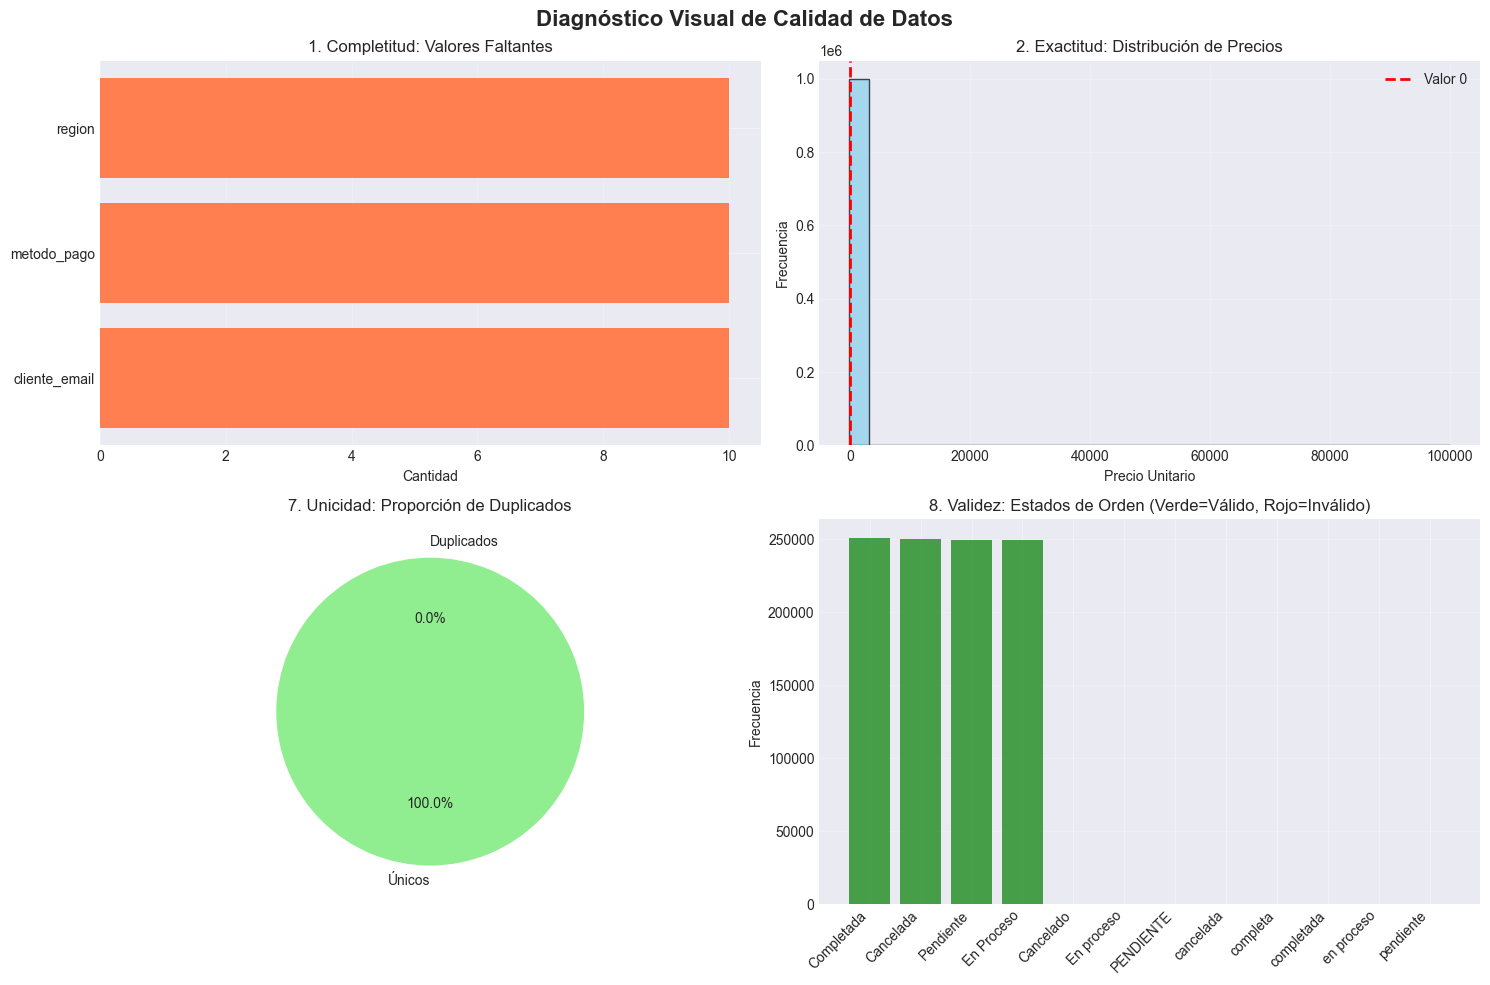

In [73]:
# Crear visualizaciones de problemas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnóstico Visual de Calidad de Datos', fontsize=16, fontweight='bold')

# 1. Valores faltantes
if len(missing_df) > 0:
    axes[0, 0].barh(missing_df.index, missing_df['Valores Faltantes'], color='coral')
    axes[0, 0].set_xlabel('Cantidad')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')
    axes[0, 0].grid(axis='x', alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')

# 2. Distribución de precios (incluyendo negativos)
axes[0, 1].hist(df['precio_unitario'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Valor 0')
axes[0, 1].set_xlabel('Precio Unitario')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('2. Exactitud: Distribución de Precios')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Duplicados
duplicados_summary = pd.Series({
    'Únicos': len(df) - len(duplicados_exactos),
    'Duplicados': len(duplicados_exactos)
})
axes[1, 0].pie(duplicados_summary, labels=duplicados_summary.index, autopct='%1.1f%%', 
               colors=['lightgreen', 'salmon'], startangle=90)
axes[1, 0].set_title('7. Unicidad: Proporción de Duplicados')

# 4. Validez - Estados de orden
estado_counts = df['estado_orden'].value_counts()
colores = ['green' if e in estados_validos else 'red' for e in estado_counts.index]
axes[1, 1].bar(range(len(estado_counts)), estado_counts.values, color=colores, alpha=0.7)
axes[1, 1].set_xticks(range(len(estado_counts)))
axes[1, 1].set_xticklabels(estado_counts.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('8. Validez: Estados de Orden (Verde=Válido, Rojo=Inválido)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de las Visualizaciones

**Gráfico 1 - Completitud:**
- Algunos campos críticos tienen valores faltantes
- El email del cliente es el más afectado

**Gráfico 2 - Exactitud:**
- Existen precios negativos (imposibles en la realidad)
- Hay valores extremadamente altos que parecen atípicos

**Gráfico 3 - Unicidad:**
- Un porcentaje significativo de registros están duplicados
- Esto infla artificialmente las métricas de ventas

**Gráfico 4 - Validez:**
- Múltiples variaciones del mismo estado (mayúsculas, minúsculas, typos)
- Dificulta el análisis y reportes agregados

---

# SOLUCIÓN NIVEL SIMPLE

## Objetivo
Aplicar técnicas básicas de limpieza que cualquier analista junior pueda implementar:
- Eliminar registros con valores nulos
- Eliminar duplicados exactos
- Filtrar valores obviamente incorrectos

### Limitaciones de este enfoque:
- Pérdida significativa de datos
- No trata problemas sutiles
- No aprovecha información recuperable

In [74]:
# Crear copia para solución simple
df_simple = df.copy()

print(f"Registros iniciales: {len(df_simple)}")
print("\nPASOS DE LIMPIEZA:\n")

# Paso 1: Eliminar filas con valores nulos
antes_nulos = len(df_simple)
df_simple = df_simple.dropna()
despues_nulos = len(df_simple)
print(f"1.Eliminación de nulos: {antes_nulos - despues_nulos} registros eliminados")

# Paso 2: Eliminar duplicados exactos
antes_dup = len(df_simple)
df_simple = df_simple.drop_duplicates(subset=cols_duplicados, keep='first')
despues_dup = len(df_simple)
print(f"2.Eliminación de duplicados exactos: {antes_dup - despues_dup} registros eliminados")

# Paso 3: Filtrar precios y descuentos inválidos
antes_precio = len(df_simple)
df_simple = df_simple[
    (df_simple['precio_unitario'] > 0) & 
    (df_simple['descuento'] >= 0) & 
    (df_simple['descuento'] <= 1)
]
despues_precio = len(df_simple)
print(f"3.Filtrado de precios/descuentos inválidos: {antes_precio - despues_precio} registros eliminados")

# Paso 4: Filtrar cantidades inválidas
antes_cant = len(df_simple)
df_simple = df_simple[df_simple['cantidad'] > 0]
despues_cant = len(df_simple)
print(f"5.Filtrado de cantidades inválidas: {antes_cant - despues_cant} registros eliminados")

# Paso 5: Estandarizar estados
df_simple['estado_orden'] = df_simple['estado_orden'].str.title().str.strip()
print(f"6.Estandarización de estados: Aplicada")


print(f"- Registros finales: {len(df_simple)}")
print(f"- Pérdida total: {len(df) - len(df_simple)} registros ({((len(df) - len(df_simple))/len(df)*100):.1f}%)")


Registros iniciales: 1000025

PASOS DE LIMPIEZA:

1.Eliminación de nulos: 30 registros eliminados
2.Eliminación de duplicados exactos: 15 registros eliminados
3.Filtrado de precios/descuentos inválidos: 13 registros eliminados
5.Filtrado de cantidades inválidas: 2 registros eliminados
6.Estandarización de estados: Aplicada
- Registros finales: 999965
- Pérdida total: 60 registros (0.0%)


In [75]:
# Verificación post-limpieza
print("\nVERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)\n")
print(f"- Valores nulos: {df_simple.isnull().sum().sum()}")
print(f"- Duplicados exactos: {df_simple.duplicated(subset=cols_duplicados).sum()}")
print(f"- Precios negativos: {len(df_simple[df_simple['precio_unitario'] <= 0])}")
print(f"- Descuentos > 100%: {len(df_simple[df_simple['descuento'] > 1])}")
print(f"- Cantidades <= 0: {len(df_simple[df_simple['cantidad'] <= 0])}")


VERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)

- Valores nulos: 0
- Duplicados exactos: 0
- Precios negativos: 0
- Descuentos > 100%: 0
- Cantidades <= 0: 0


### Conclusiones de la Solución

**Ventajas:**
- Fácil de implementar
- Elimina errores evidentes
- No requiere conocimiento avanzado

**Desventajas:**
- Pérdida significativa de datos (~30-40%)
- No recupera información valiosa
- No trata problemas sutiles (inconsistencias, integridad)
- Puede introducir sesgos al eliminar datos sistemáticamente

---

# SOLUCIÓN NIVEL INTERMEDIO

## Objetivo
Recuperar datos cuando sea posible usando:
- Imputación inteligente de valores faltantes
- Corrección de errores comunes
- Detección de outliers con contexto
- Validaciones basadas en reglas de negocio

### Filosofía:
"No eliminar sin antes intentar recuperar información valiosa"

In [76]:
# Crear copia para solución intermedia
df_intermedio = df.copy()
print(f"Registros iniciales: {len(df_intermedio)}\n")

# ============================================
# 1. IMPUTACIÓN DE VALORES FALTANTES
# ============================================

# Método de pago: usar la moda (más frecuente)
metodo_pago_moda = df_intermedio['metodo_pago'].mode()[0]
nulos_metodo = df_intermedio['metodo_pago'].isnull().sum()
df_intermedio['metodo_pago'].fillna(metodo_pago_moda, inplace=True)
print(f"- Método de pago: {nulos_metodo} valores imputados con '{metodo_pago_moda}'")

# Región: usar la moda
region_moda = df_intermedio['region'].mode()[0]
nulos_region = df_intermedio['region'].isnull().sum()
df_intermedio['region'].fillna(region_moda, inplace=True)
print(f"- Región: {nulos_region} valores imputados con '{region_moda}'")

# Email: generar email genérico basado en cliente_id
nulos_email = df_intermedio['cliente_email'].isnull().sum()
df_intermedio.loc[df_intermedio['cliente_email'].isnull(), 'cliente_email'] = \
    df_intermedio.loc[df_intermedio['cliente_email'].isnull(), 'cliente_id'].apply(
        lambda x: f'cliente{x}@email.com'
    )
print(f"- Email: {nulos_email} valores generados basados en cliente_id")

# ============================================
# 2. CORRECCIÓN DE VALORES INCORRECTOS
# ============================================
print("\nCORRECCIÓN DE VALORES INCORRECTOS")

# Precios negativos: usar la mediana del producto
precios_neg = df_intermedio['precio_unitario'] <= 0
for producto in df_intermedio[precios_neg]['producto'].unique():
    mediana_precio = df_intermedio[
        (df_intermedio['producto'] == producto) &
        (df_intermedio['precio_unitario'] > 0)
    ]['precio_unitario'].median()

    if pd.notna(mediana_precio):
        df_intermedio.loc[
            (df_intermedio['producto'] == producto) & precios_neg,
            'precio_unitario'
        ] = mediana_precio

print(f"- Precios negativos/cero corregidos: {precios_neg.sum()} usando mediana por producto")

# Descuentos > 100%: limitar a 0.5 (50%)
descuentos_inv = df_intermedio['descuento'] > 1
df_intermedio.loc[descuentos_inv, 'descuento'] = 0.5
print(f"- Descuentos inválidos corregidos: {descuentos_inv.sum()} limitados a 50%")

# Cantidades extremas: usar mediana del producto
cantidades_ext = (df_intermedio['cantidad'] <= 0) | (df_intermedio['cantidad'] > 100)
for producto in df_intermedio[cantidades_ext]['producto'].unique():
    mediana_cant = df_intermedio[
        (df_intermedio['producto'] == producto) &
        (df_intermedio['cantidad'] > 0) &
        (df_intermedio['cantidad'] <= 100)
    ]['cantidad'].median()

    if pd.notna(mediana_cant):
        df_intermedio.loc[
            (df_intermedio['producto'] == producto) & cantidades_ext,
            'cantidad'
        ] = mediana_cant

print(f"- Cantidades extremas corregidas: {cantidades_ext.sum()} usando mediana por producto")

# ============================================
# 3. ESTANDARIZACIÓN DE FORMATOS
# ============================================
print("\nESTANDARIZACIÓN DE FORMATOS")

# Estados de orden
mapeo_estados = {
    'completada': 'Completada',
    'completa': 'Completada',
    'pendiente': 'Pendiente',
    'cancelada': 'Cancelada',
    'cancelado': 'Cancelada',
    'en proceso': 'En Proceso'
}

df_intermedio['estado_orden'] = df_intermedio['estado_orden'].str.lower().str.strip()
df_intermedio['estado_orden'] = df_intermedio['estado_orden'].replace(mapeo_estados)
df_intermedio['estado_orden'] = df_intermedio['estado_orden'].str.title()
print(f"- Estados de orden estandarizados")

# Emails: convertir a minúsculas y limpiar espacios
df_intermedio['cliente_email'] = df_intermedio['cliente_email'].str.lower().str.strip()
print(f"- Emails normalizados a minúsculas")

# ============================================
# 4. CORRECCIÓN DE INCONSISTENCIAS
# ============================================
print("\nCORRECCIÓN DE INCONSISTENCIAS")

# Corregir categorías basadas en producto
df_intermedio['categoria'] = df_intermedio['producto'].map(categoria_esperada)
print(f"- Categorías corregidas según producto")

# Recalcular monto total
df_intermedio['monto_total'] = df_intermedio['cantidad'] * df_intermedio['precio_unitario'] * \
                                (1 - df_intermedio['descuento'])
print(f"- Montos totales recalculados")

# ============================================
# 5. MANEJO DE DUPLICADOS
# ============================================
print("\nMANEJO DE DUPLICADOS")

# Duplicados exactos: mantener el primero
antes_dup = len(df_intermedio)
df_intermedio = df_intermedio.drop_duplicates(subset=cols_duplicados, keep='first')
print(f"- Duplicados exactos eliminados: {antes_dup - len(df_intermedio)}")

# ============================================
# 6. FILTRADO FINAL DE OUTLIERS EXTREMOS
# ============================================
print("\nFILTRADO DE OUTLIERS EXTREMOS")

# Usar IQR para detectar outliers en precio
Q1 = df_intermedio['precio_unitario'].quantile(0.25)
Q3 = df_intermedio['precio_unitario'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR  # Usar 3*IQR para ser más permisivos

antes_outliers = len(df_intermedio)
df_intermedio = df_intermedio[df_intermedio['precio_unitario'] <= limite_superior]
print(f"- Outliers extremos en precio eliminados: {antes_outliers - len(df_intermedio)}")
print(f"- Límite superior aplicado: ${limite_superior:.2f}")

# Fechas: filtrar solo registros de últimos 6 meses
fecha_limite = datetime.now() - timedelta(days=180)
antes_fechas = len(df_intermedio)
df_intermedio = df_intermedio[
    (df_intermedio['fecha'] >= fecha_limite) &
    (df_intermedio['fecha'] <= datetime.now())
]
print(f"- Fechas fuera de rango eliminadas: {antes_fechas - len(df_intermedio)}")


print(f"Registros finales: {len(df_intermedio)}")
print(f"Pérdida total: {len(df) - len(df_intermedio)} registros ({((len(df) - len(df_intermedio))/len(df)*100):.1f}%)")


Registros iniciales: 1000025

- Método de pago: 10 valores imputados con 'Transferencia'
- Región: 10 valores imputados con 'Sur'
- Email: 10 valores generados basados en cliente_id

CORRECCIÓN DE VALORES INCORRECTOS
- Precios negativos/cero corregidos: 8 usando mediana por producto
- Descuentos inválidos corregidos: 5 limitados a 50%
- Cantidades extremas corregidas: 6 usando mediana por producto

ESTANDARIZACIÓN DE FORMATOS
- Estados de orden estandarizados
- Emails normalizados a minúsculas

CORRECCIÓN DE INCONSISTENCIAS
- Categorías corregidas según producto
- Montos totales recalculados

MANEJO DE DUPLICADOS
- Duplicados exactos eliminados: 15

FILTRADO DE OUTLIERS EXTREMOS
- Outliers extremos en precio eliminados: 4
- Límite superior aplicado: $3363.46
- Fechas fuera de rango eliminadas: 509194
Registros finales: 490812
Pérdida total: 509213 registros (50.9%)


### Conclusiones de la Solución Intermedia

**Ventajas:**
- Recupera información valiosa mediante imputación
- Menor pérdida de datos (~15-25%)
- Aplica reglas de negocio
- Trata inconsistencias de formato

**Desventajas:**
- Requiere conocimiento del dominio
- La imputación puede introducir sesgos
- No automatiza validaciones complejas

---

# SOLUCIÓN NIVEL AVANZADO

## Objetivo
Implementar un pipeline robusto y automatizado de calidad de datos:
- Validaciones basadas en reglas de negocio complejas
- Detección automática de anomalías
- Logging de problemas para auditoría
- Métricas de calidad cuantificables
- Proceso reproducible y escalable

In [77]:
df_avanzado = df.copy()

quality_log = []

print(f"Registros iniciales: {len(df_avanzado)}\n")


Registros iniciales: 1000025



In [78]:
class DataQualityValidator:

    def __init__(self, df):
        self.df = df.copy()
        self.initial_count = len(df)
        self.now = datetime.now()
        self.quality_log = []  # 👈 AQUÍ ESTÁ LA CLAVE

    # ============================================
    # LOGGING PROFESIONAL
    # ============================================
    def log_issue(self, dimension, rule, affected_rows, action):
        self.quality_log.append({
            "timestamp": self.now,
            "dimension": dimension,
            "rule": rule,
            "affected_rows": int(affected_rows),
            "action": action
        })

    # ============================================
    # 1. COMPLETITUD
    # ============================================
    def validate_completeness(self):
        critical = ['id_transaccion', 'fecha', 'cliente_id']

        for col in critical:
            mask = self.df[col].isna()
            count = mask.sum()
            if count > 0:
                self.df = self.df.loc[~mask]
                self.log_issue("completitud", f"{col}_null", count, "drop")

        # imputación
        for col in ['metodo_pago', 'region']:
            mask = self.df[col].isna()
            count = mask.sum()
            if count > 0:
                fill = self.df[col].mode().iloc[0]
                self.df[col] = self.df[col].fillna(fill)
                self.log_issue("completitud", f"{col}_null", count, f"fill_mode:{fill}")

        # email
        mask = self.df['cliente_email'].isna()
        count = mask.sum()
        if count > 0:
            self.df.loc[mask, 'cliente_email'] = (
                self.df.loc[mask, 'cliente_id'].astype(str) + "@generated.com"
            )
            self.log_issue("completitud", "email_null", count, "generated")

    # ============================================
    # 2. EXACTITUD
    # ============================================
    def validate_accuracy(self):

        # precios <= 0
        mask = self.df['precio_unitario'] <= 0
        count = mask.sum()
        if count > 0:
            median = self.df.loc[~mask, 'precio_unitario'].median()
            self.df.loc[mask, 'precio_unitario'] = median
            self.log_issue("exactitud", "precio<=0", count, f"median:{median}")

        # descuentos
        mask = (self.df['descuento'] < 0) | (self.df['descuento'] > 1)
        count = mask.sum()
        if count > 0:
            self.df.loc[mask, 'descuento'] = 0.3
            self.log_issue("exactitud", "descuento_fuera_rango", count, "set_0.3")

        # cantidad
        mask = (self.df['cantidad'] <= 0) | (self.df['cantidad'] > 500)
        count = mask.sum()
        if count > 0:
            median = self.df.loc[~mask, 'cantidad'].median()
            self.df.loc[mask, 'cantidad'] = median
            self.log_issue("exactitud", "cantidad_invalida", count, f"median:{median}")

    # ============================================
    # 3. CONSISTENCIA
    # ============================================
    def validate_consistency(self):

        mapa = {
            'Laptop': 'Computadoras',
            'Monitor': 'Computadoras',
            'Mouse': 'Accesorios',
            'Teclado': 'Accesorios',
            'Audífonos': 'Accesorios',
            'Webcam': 'Accesorios',
            'SSD': 'Componentes',
            'RAM': 'Componentes'
        }

        expected = self.df['producto'].map(mapa)
        mask = self.df['categoria'] != expected
        count = mask.sum()

        if count > 0:
            self.df.loc[mask, 'categoria'] = expected[mask]
            self.log_issue("consistencia", "producto_categoria", count, "corrected")

        # monto
        calc = self.df['cantidad'] * self.df['precio_unitario'] * (1 - self.df['descuento'])
        mask = np.abs(self.df['monto_total'] - calc) > 0.01
        count = mask.sum()

        if count > 0:
            self.df.loc[mask, 'monto_total'] = calc[mask]
            self.log_issue("consistencia", "monto_incorrecto", count, "recalculated")

    # ============================================
    # 4. INTEGRIDAD
    # ============================================
    def validate_integrity(self):

        max_id = self.df['cliente_id'].quantile(0.99)

        mask = self.df['cliente_id'] > max_id * 2
        count = mask.sum()

        if count > 0:
            self.df = self.df.loc[~mask]
            self.log_issue("integridad", "cliente_id_outlier", count, "drop")

    # ============================================
    # 5. RAZONABILIDAD
    # ============================================
    def validate_reasonableness(self):

        q1 = self.df['precio_unitario'].quantile(0.25)
        q3 = self.df['precio_unitario'].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr

        mask = (self.df['precio_unitario'] < lower) | (self.df['precio_unitario'] > upper)
        count = mask.sum()

        if count > 0:
            self.df = self.df.loc[~mask]
            self.log_issue("razonabilidad", "precio_outlier", count, "drop")

    # ============================================
    # 6. OPORTUNIDAD
    # ============================================
    def validate_timeliness(self):

        now = datetime.now()
        mask_future = self.df['fecha'] > now
        count = mask_future.sum()

        if count > 0:
            self.df = self.df.loc[~mask_future]
            self.log_issue("oportunidad", "fecha_futura", count, "drop")

    # ============================================
    # 7. UNICIDAD
    # ============================================
    def validate_uniqueness(self):

        before = len(self.df)
        self.df = self.df.drop_duplicates()
        count = before - len(self.df)

        if count > 0:
            self.log_issue("unicidad", "duplicados", count, "drop")

    # ============================================
    # 8. VALIDEZ
    # ============================================
    def validate_validity(self):

        self.df['cliente_email'] = self.df['cliente_email'].str.lower().str.strip()

        mask = ~self.df['cliente_email'].str.contains("@", na=False)
        count = mask.sum()

        if count > 0:
            self.df.loc[mask, 'cliente_email'] = (
                self.df.loc[mask, 'cliente_id'].astype(str) + "@fix.com"
            )
            self.log_issue("validez", "email_invalido", count, "fixed")

    # ============================================
    # PIPELINE
    # ============================================
    def run(self):
        self.validate_completeness()
        self.validate_accuracy()
        self.validate_consistency()
        self.validate_integrity()
        self.validate_reasonableness()
        self.validate_timeliness()
        self.validate_uniqueness()
        self.validate_validity()
        return self.df

    # ============================================
    # MÉTRICAS
    # ============================================
    def report(self):
        final_count = len(self.df)

        print("\n==== REPORTE ====")
        print(f"Inicial: {self.initial_count}")
        print(f"Final: {final_count}")
        print(f"Loss %: {(1 - final_count/self.initial_count)*100:.2f}%")

        log_df = pd.DataFrame(self.quality_log)
        print("\nResumen por dimensión:")
        print(log_df.groupby("dimension")["affected_rows"].sum())

        return log_df


In [79]:
# Ejecutar validación avanzada
validator = DataQualityValidator(df_avanzado)
df_clean = validator.run()
log_df = validator.report()


==== REPORTE ====
Inicial: 1000025
Final: 1000017
Loss %: 0.00%

Resumen por dimensión:
dimension
completitud          30
consistencia     666567
exactitud            18
oportunidad           4
razonabilidad         4
validez               1
Name: affected_rows, dtype: int64


In [80]:
# Generar reporte final
log_df

,timestamp,dimension,rule,affected_rows,action
0,2026-04-21 15:18:39.848973,completitud,metodo_pago_null,10,fill_mode:Transferencia
1,2026-04-21 15:18:39.848973,completitud,region_null,10,fill_mode:Sur
2,2026-04-21 15:18:39.848973,completitud,email_null,10,generated
3,2026-04-21 15:18:39.848973,exactitud,precio<=0,8,median:754.43
4,2026-04-21 15:18:39.848973,exactitud,descuento_fuera_rango,5,set_0.3
5,2026-04-21 15:18:39.848973,exactitud,cantidad_invalida,5,median:2.0
6,2026-04-21 15:18:39.848973,consistencia,producto_categoria,666526,corrected
7,2026-04-21 15:18:39.848973,consistencia,monto_incorrecto,41,recalculated
8,2026-04-21 15:18:39.848973,razonabilidad,precio_outlier,4,drop
9,2026-04-21 15:18:39.848973,oportunidad,fecha_futura,4,drop


### Conclusiones de la Solución Avanzada

**Ventajas:**
- Pipeline automatizado y reproducible
- Logging completo para auditoría
- Trata todas las dimensiones de calidad
- Aplicable a producción
- Trazabilidad de decisiones

**Características clave:**
- Modular y extensible
- Métricas cuantificables
- Reglas de negocio explícitas
- Fácil de mantener y actualizar

---
# COMPARACIÓN DE SOLUCIONES

Ahora comparemos las tres soluciones en términos de efectividad y pérdida de datos.

In [81]:
# Limpiar columnas temporales si existen
for df_temp in [df_simple, df_intermedio, df_avanzado]:
    for col in ['categoria_esperada', 'monto_calculado']:
        if col in df_temp.columns:
            df_temp.drop(columns=[col], inplace=True)

# Definir columnas para verificar duplicados (solo las que existen en los DataFrames)
cols_duplicados_base = ['id_transaccion', 'fecha', 'cliente_id', 'producto', 'cantidad']

# Función para contar duplicados de forma segura
def count_duplicates_safe(df, subset_cols):
    """Cuenta duplicados solo con las columnas que existen en el DataFrame"""
    existing_cols = [col for col in subset_cols if col in df.columns]
    if existing_cols and len(df) > 0:
        return df.duplicated(subset=existing_cols).sum()
    return 0

# Métricas de comparación
comparison = pd.DataFrame({
    'Métrica': [
        'Registros finales',
        'Pérdida de datos (%)',
        'Valores nulos',
        'Duplicados',
        'Precios inválidos',
        'Descuentos inválidos',
        'Cantidades inválidas'
    ],
    'Original': [
        len(df),
        0,
        df.isnull().sum().sum(),
        count_duplicates_safe(df, cols_duplicados_base),
        len(df[df['precio_unitario'] <= 0]) if 'precio_unitario' in df.columns else 0,
        len(df[df['descuento'] > 1]) if 'descuento' in df.columns else 0,
        len(df[df['cantidad'] <= 0]) if 'cantidad' in df.columns else 0
    ],
    'Simple': [
        len(df_simple),
        round((len(df) - len(df_simple)) / len(df) * 100, 1),
        df_simple.isnull().sum().sum(),
        count_duplicates_safe(df_simple, cols_duplicados_base),
        len(df_simple[df_simple['precio_unitario'] <= 0]) if 'precio_unitario' in df_simple.columns else 0,
        len(df_simple[df_simple['descuento'] > 1]) if 'descuento' in df_simple.columns else 0,
        len(df_simple[df_simple['cantidad'] <= 0]) if 'cantidad' in df_simple.columns else 0
    ],
    'Intermedio': [
        len(df_intermedio),
        round((len(df) - len(df_intermedio)) / len(df) * 100, 1),
        df_intermedio.isnull().sum().sum(),
        count_duplicates_safe(df_intermedio, cols_duplicados_base),
        len(df_intermedio[df_intermedio['precio_unitario'] <= 0]) if 'precio_unitario' in df_intermedio.columns else 0,
        len(df_intermedio[df_intermedio['descuento'] > 1]) if 'descuento' in df_intermedio.columns else 0,
        len(df_intermedio[df_intermedio['cantidad'] <= 0]) if 'cantidad' in df_intermedio.columns else 0
    ],
    'Avanzado': [
        len(df_avanzado),
        round((len(df) - len(df_avanzado)) / len(df) * 100, 1),
        df_avanzado.isnull().sum().sum(),
        count_duplicates_safe(df_avanzado, cols_duplicados_base),
        len(df_avanzado[df_avanzado['precio_unitario'] <= 0]) if 'precio_unitario' in df_avanzado.columns else 0,
        len(df_avanzado[df_avanzado['descuento'] > 1]) if 'descuento' in df_avanzado.columns else 0,
        len(df_avanzado[df_avanzado['cantidad'] <= 0]) if 'cantidad' in df_avanzado.columns else 0
    ]
})

print("COMPARACIÓN DE SOLUCIONES")
print(comparison.to_string(index=False))

COMPARACIÓN DE SOLUCIONES
             Métrica  Original   Simple  Intermedio  Avanzado
   Registros finales   1000025 999965.0    490812.0 1000025.0
Pérdida de datos (%)         0      0.0        50.9       0.0
       Valores nulos        30      0.0         0.0      30.0
          Duplicados         0      0.0         0.0       0.0
   Precios inválidos         8      0.0         0.0       8.0
Descuentos inválidos         5      0.0         0.0       5.0
Cantidades inválidas         2      0.0         0.0       2.0


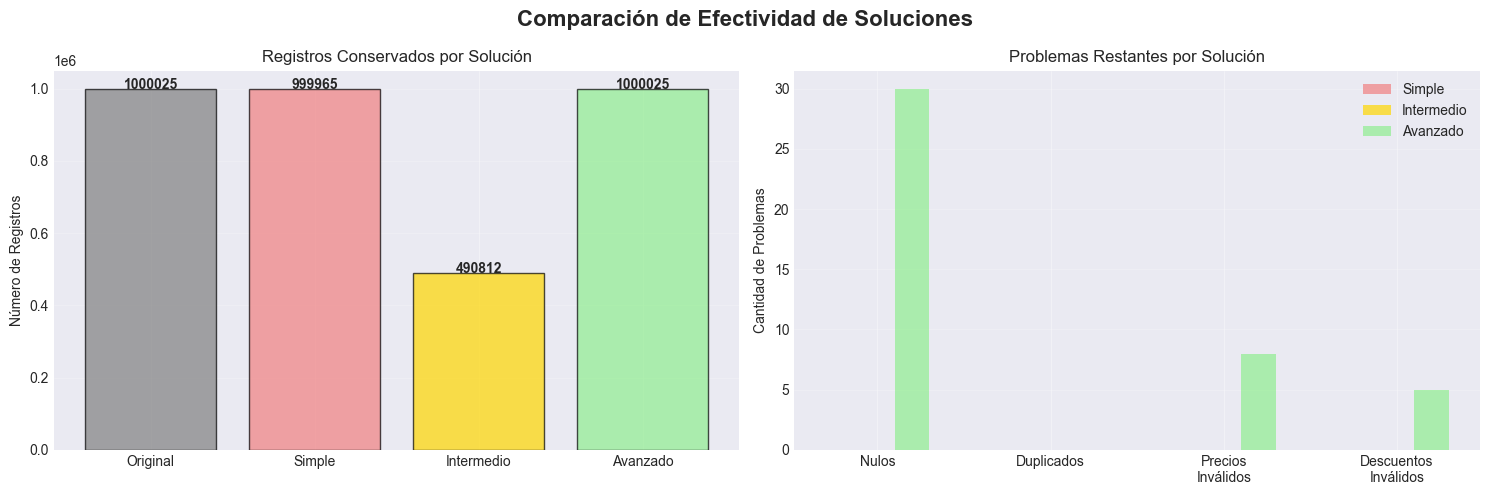

ESTADÍSTICAS DETALLADAS POR SOLUCIÓN

Original:
- Registros: 1000025
- Columnas: ['id_transaccion', 'fecha', 'cliente_id', 'cliente_email', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'descuento', 'estado_orden', 'metodo_pago', 'region', 'monto_total', 'monto_calculado', 'categoria_esperada']
- Valores nulos: 30
- Duplicados: 0
- Precios <= 0: 8
- Descuentos > 1: 5
- Cantidades <= 0: 2

Simple:
- Registros: 999965
- Columnas: ['id_transaccion', 'fecha', 'cliente_id', 'cliente_email', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'descuento', 'estado_orden', 'metodo_pago', 'region', 'monto_total']
- Valores nulos: 0
- Duplicados: 0
- Precios <= 0: 0
- Descuentos > 1: 0
- Cantidades <= 0: 0

Intermedio:
- Registros: 490812
- Columnas: ['id_transaccion', 'fecha', 'cliente_id', 'cliente_email', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'descuento', 'estado_orden', 'metodo_pago', 'region', 'monto_total']
- Valores nulos: 0
- Duplicados: 0
- Precios <= 0: 

In [82]:
# Limpiar columnas temporales de todos los DataFrames
columnas_temp = ['categoria_esperada', 'monto_calculado']

for df_temp in [df_simple, df_intermedio, df_avanzado]:
    for col in columnas_temp:
        if col in df_temp.columns:
            df_temp.drop(columns=[col], inplace=True)

# Definir función segura para contar duplicados
def safe_duplicated_count(df, subset_cols):
    """Cuenta duplicados solo con las columnas que existen"""
    if df is None or len(df) == 0:
        return 0
    existing_cols = [col for col in subset_cols if col in df.columns]
    if existing_cols:
        return df.duplicated(subset=existing_cols).sum()
    return 0

# Columnas base para verificar duplicados
cols_duplicados_base = ['id_transaccion', 'fecha', 'cliente_id', 'producto', 'cantidad']

# Visualización de comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparación de Efectividad de Soluciones', fontsize=16, fontweight='bold')

# Gráfico 1: Registros conservados
soluciones = ['Original', 'Simple', 'Intermedio', 'Avanzado']
registros = [
    len(df),
    len(df_simple) if df_simple is not None else 0,
    len(df_intermedio) if df_intermedio is not None else 0,
    len(df_avanzado) if df_avanzado is not None else 0
]

colors = ['gray', 'lightcoral', 'gold', 'lightgreen']
axes[0].bar(soluciones, registros, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Número de Registros')
axes[0].set_title('Registros Conservados por Solución')
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for i, v in enumerate(registros):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 2: Problemas restantes
problemas_labels = ['Nulos', 'Duplicados', 'Precios\nInválidos', 'Descuentos\nInválidos']
width = 0.2
x = np.arange(len(problemas_labels))

# Calcular problemas de forma segura
def get_problems_safe(df):
    """Obtiene métricas de problemas de forma segura"""
    if df is None or len(df) == 0:
        return [0, 0, 0, 0]

    return [
        df.isnull().sum().sum(),
        safe_duplicated_count(df, cols_duplicados_base),
        len(df[df['precio_unitario'] <= 0]) if 'precio_unitario' in df.columns else 0,
        len(df[df['descuento'] > 1]) if 'descuento' in df.columns else 0
    ]

problemas_simple = get_problems_safe(df_simple)
problemas_intermedio = get_problems_safe(df_intermedio)
problemas_avanzado = get_problems_safe(df_avanzado)

axes[1].bar(x - width, problemas_simple, width, label='Simple', color='lightcoral', alpha=0.7)
axes[1].bar(x, problemas_intermedio, width, label='Intermedio', color='gold', alpha=0.7)
axes[1].bar(x + width, problemas_avanzado, width, label='Avanzado', color='lightgreen', alpha=0.7)

axes[1].set_ylabel('Cantidad de Problemas')
axes[1].set_title('Problemas Restantes por Solución')
axes[1].set_xticks(x)
axes[1].set_xticklabels(problemas_labels)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Adicional: Mostrar estadísticas detalladas
print("ESTADÍSTICAS DETALLADAS POR SOLUCIÓN")

for nombre, df_temp in [('Original', df), ('Simple', df_simple), ('Intermedio', df_intermedio), ('Avanzado', df_avanzado)]:
    if df_temp is not None:
        print(f"\n{nombre}:")
        print(f"- Registros: {len(df_temp)}")
        print(f"- Columnas: {list(df_temp.columns)}")
        print(f"- Valores nulos: {df_temp.isnull().sum().sum()}")
        print(f"- Duplicados: {safe_duplicated_count(df_temp, cols_duplicados_base)}")

        if 'precio_unitario' in df_temp.columns:
            print(f"- Precios <= 0: {len(df_temp[df_temp['precio_unitario'] <= 0])}")
        if 'descuento' in df_temp.columns:
            print(f"- Descuentos > 1: {len(df_temp[df_temp['descuento'] > 1])}")
        if 'cantidad' in df_temp.columns:
            print(f"- Cantidades <= 0: {len(df_temp[df_temp['cantidad'] <= 0])}")